### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import requests

import re
import nltk
from nltk.corpus import stopwords
import pymorphy3
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from bs4 import BeautifulSoup
from itertools import cycle

In [2]:
%matplotlib inline

### Загрузка файлов

In [3]:
pos_df = pd.read_csv('pos.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')
neg_df = pd.read_csv('neg.csv', sep=';', header=None, usecols=[3, 4], 
                    names=['text', 'sentiment'], encoding='utf-8', engine='python')

#### Включенные поля:
- text: Основной признак. Содержит лексико-семантическую информацию, необходимую для оценки эмоциональной окраски
- sentiment: Целевая переменная. Метка класса (1 — позитив, -1 — негатив)

#### Исключенные поля (исходные индексы 0, 1, 2, 5-11):
- tweet_id: Уникальный технический идентификатор. Не несет лингвистического смысла
- timestamp: Время публикации. Не определяет тональность текста
- username: Автор поста. Не влияет на семантику сообщения
- Метрики вовлеченности и служебные флаги (лайки, ретвиты, ответы). Не являются причиной тональности

### Создание датасетов с ключевыми колонками: текст поста и метка тональности

In [4]:
pos_df = pd.read_csv('pos.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')
neg_df = pd.read_csv('neg.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')

In [5]:
# Слияние классов в единую таблицу
dataset = pd.concat([pos_df, neg_df], ignore_index=True)

### Очистка от битых и пустых строк

In [6]:
# Очистка от битых/пустых строк
dataset.dropna(subset=['text'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

### Проверка итоговой структуры датасета

In [7]:
print("Названия колонок:", list(dataset.columns))
dataset.shape
dataset['sentiment'].value_counts()

Названия колонок: ['text', 'sentiment']


sentiment
 1    114911
-1    111923
Name: count, dtype: int64

In [8]:
dataset.head()

,text,sentiment
0,"@first_timee хоть я и школота, но поверь, у на...",1
1,"Да, все-таки он немного похож на него. Но мой ...",1
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1


## Предварительная обработка текста

In [9]:
# Загрузка стоп-слов и инициализация анализатора
nltk.download('stopwords', quiet=True)
RU_STOPWORDS = set(stopwords.words('russian'))
MORPH = pymorphy3.MorphAnalyzer()

In [10]:
def preprocess_tweet(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^а-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    lemmatized = [
        MORPH.parse(w)[0].normal_form 
        for w in words 
        if w not in RU_STOPWORDS and len(w) > 2
    ]
    return ' '.join(lemmatized)

dataset['text_clean'] = dataset['text'].apply(preprocess_tweet)
dataset = dataset[dataset['text_clean'].str.len() > 0].reset_index(drop=True)

In [11]:
# Проверка результата
for i in range(3):
    print(f"Оригинал : {dataset['text'].iloc[i]}")
    print(f"Обработано: {dataset['text_clean'].iloc[i]}\n")

print(f"Записей после очистки: {len(dataset)}")

Оригинал : @first_timee хоть я и школота, но поверь, у нас то же самое :D общество профилирующий предмет типа)
Обработано: школотый поверь самый общество профилировать предмет тип

Оригинал : Да, все-таки он немного похож на него. Но мой мальчик все равно лучше:D
Обработано: всетаки немного похожий мальчик равно

Оригинал : RT @KatiaCheh: Ну ты идиотка) я испугалась за тебя!!!
Обработано: идиотка испугаться

Записей после очистки: 226200


## Тематическое моделирование положительных и отрицательных постов

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import warnings
warnings.filterwarnings('ignore')

## Облака слов

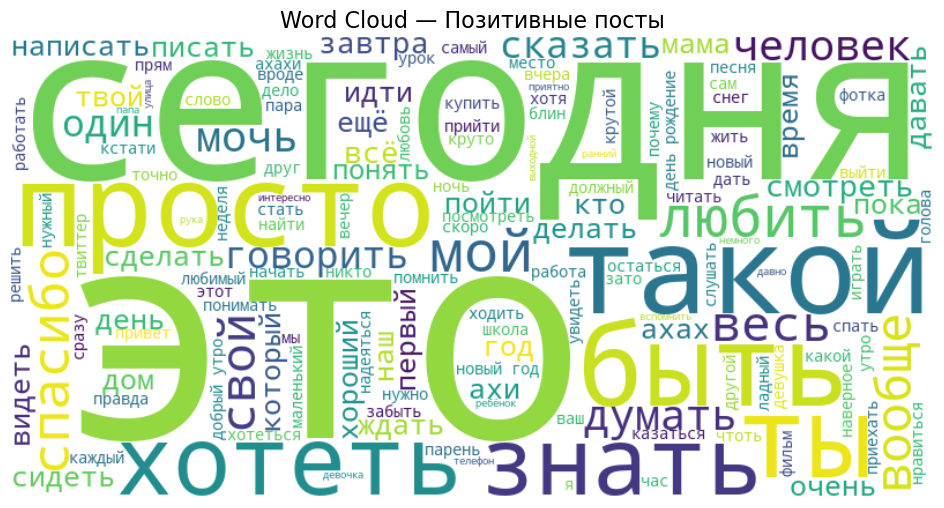

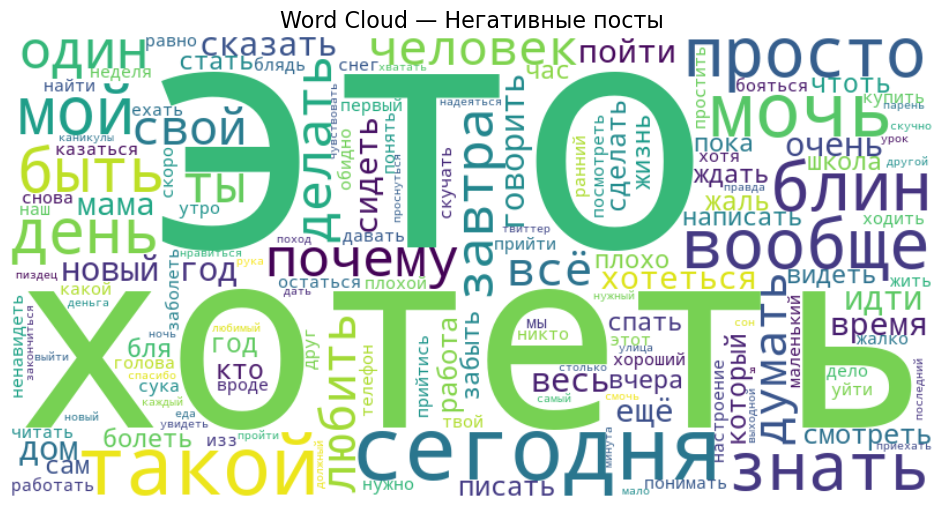

In [13]:
pos_text = ' '.join(dataset[dataset['sentiment'] == 1]['text_clean'])
neg_text = ' '.join(dataset[dataset['sentiment'] == -1]['text_clean'])

# Позитивные посты
plt.figure(figsize=(12, 6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(pos_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Позитивные посты', fontsize=16)
plt.show()

# Негативные посты
plt.figure(figsize=(12, 6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(neg_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Негативные посты', fontsize=16)
plt.show()

## Векторизация

In [14]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(dataset['text_clean'])
print(f"Размер TF-IDF матрицы: {X.shape}")

Размер TF-IDF матрицы: (226200, 5000)


In [15]:
feature_names = vectorizer.get_feature_names_out()
print("Примеры признаков:", feature_names[:50])

Примеры признаков: ['ааа' 'аааа' 'ааааа' 'аааааа' 'ааааааа' 'аааааааа' 'абсолютно' 'ава'
 'авария' 'аватарка' 'август' 'авто' 'автобус' 'автомат' 'автомобиль'
 'автор' 'ага' 'ад' 'адекватный' 'админ' 'адрес' 'адский' 'азаза'
 'азазаза' 'айпад' 'айпада' 'айса' 'айфон' 'академия' 'акк' 'аккаунт'
 'аккуратный' 'активно' 'активный' 'актриса' 'актуальный' 'актёр' 'акция'
 'алгебра' 'але' 'александр' 'ален' 'алина' 'алиса' 'алкоголь' 'аллергия'
 'альбом' 'алёна' 'америка' 'американец']


#### Вывод
В данном наборе признаков много сленговых и разговорных слов, смысловую нагрузку которых сложно определить. Посмотрим, как это повлияет на определение тем для позитивных и негативных постов

#### Пример вектора для одного документа

In [16]:
sample_idx = 0
sample_vector = X[sample_idx]
non_zero = sample_vector.nonzero()[1]
print("Токены в первом документе:", [feature_names[i] for i in non_zero[:10]])
print("Соответствующие веса:", sample_vector.data[:10])

Токены в первом документе: ['поверь', 'самый', 'общество', 'предмет', 'тип']
Соответствующие веса: [0.53800967 0.30623665 0.48434098 0.4726292  0.39849739]


## Тематическое моделирование

In [17]:
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"Тема {topic_idx}: {', '.join(top_words)}")

# Общий датасет
nmf = NMF(n_components=6, random_state=42)
nmf.fit(X)

print("\nТемы для всего датасета")
print_topics(nmf, vectorizer.get_feature_names_out())

# Позитивные посты
X_pos = vectorizer.transform(dataset[dataset['sentiment'] == 1]['text_clean'])
nmf_pos = NMF(n_components=5, random_state=42)
nmf_pos.fit(X_pos)

print("\nТемы позитивных постов")
print_topics(nmf_pos, vectorizer.get_feature_names_out())

# Негативные посты
X_neg = vectorizer.transform(dataset[dataset['sentiment'] == -1]['text_clean'])
nmf_neg = NMF(n_components=5, random_state=42)
nmf_neg.fit(X_neg)

print("\nТемы негативных постов")
print_topics(nmf_neg, vectorizer.get_feature_names_out())


Темы для всего датасета
Тема 0: это, просто, самый, думать, это просто, очень, человек, всё, время, мой
Тема 1: день, сегодня, весь, завтра, рождение, быть, день рождение, хороший, утро, мой
Тема 2: хотеть, спать, хотеть спать, блин, идти, посмотреть, мочь, никто, спать хотеть, хотеть хотеть
Тема 3: год, новый, новый год, настроение, скоро, ёлка, быть, новогодний, подарок, скоро новый
Тема 4: такой, человек, почему, мочь, просто, вообще, видеть, один, говорить, смотреть
Тема 5: ты, знать, любить, спасибо, очень, просто, быть, человек, сказать, говорить

Темы позитивных постов
Тема 0: это, просто, это просто, знать это, самый, круто, сказать, это очень, думать, знать
Тема 1: день, сегодня, рождение, день рождение, хороший, добрый, весь, утро, добрый утро, сегодня день
Тема 2: спасибо, большой, спасибо ты, приятно, спасибо большой, очень, весь, хороший, вечер, спасибо весь
Тема 3: ты, спасибо ты, нужный, привет, удача, твой, новый, нравиться, добро, сон
Тема 4: такой, любить, быть, знат

#### Вывод
Стандартный стоп-лист недостаточен. В данном случае стоп-лист не покрывает сленговые выражения, повторы и другие разговорные слова. Будем проводить улучшение векторизации

### Улучшение векторизации

#### Дополняем множеств русских стоп-слов своими

In [18]:
stop_words = set(stopwords.words('russian'))
extra_stopwords = {
    'это', 'просто', 'очень', 'очень очень', 'привет', 'спасибо',
    'пока', 'ну', 'ага', 'угу', 'ладно', 'хорошо', 'ок', 'спс',
    'да', 'нет', 'как', 'что', 'так', 'все', 'весь', 'уже', 'ещё',
    'ну', 'даже', 'прям', 'реально', 'короче', 'типа', 'вроде', 'типо'
    'почему', 'поэтому', 'потому'
}
stop_words.update(extra_stopwords)

#### Проводим улучшенную векторизацию

Убираем слова, встречающиеся более 85% в документе

In [19]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.85, 
    ngram_range=(1, 2),
    stop_words=list(extra_stopwords),
)

#### Применяем новый векторизатор

In [20]:
X_tfidf = tfidf_vectorizer.fit_transform(dataset['text_clean'])

#### Проводим тематическое моделирование

In [21]:
nmf = NMF(n_components=10, random_state=42, init='nndsvd')
nmf.fit(X_tfidf)

feature_names = tfidf_vectorizer.get_feature_names_out()

#### Вывод тем

In [22]:
for i, weights in enumerate(nmf.components_):
    top_idx = weights.argsort()[:-11:-1]
    keywords = [f"{feature_names[i]} ({weights[i]:.3f})" for i in top_idx]
    print(f"Тема {i}: {', '.join(keywords)}")

Тема 0: день (7.919), рождение (1.706), день рождение (1.692), хороший (0.681), каждый (0.619), каждый день (0.584), целый (0.463), целый день (0.456), добрый (0.410), утро (0.374)
Тема 1: хотеть (4.870), спать (0.313), хотеть спать (0.190), хотеть хотеть (0.129), спать хотеть (0.121), посмотреть (0.107), никто (0.096), домой (0.095), никто хотеть (0.084), идти (0.083)
Тема 2: год (3.213), новый (2.896), новый год (2.171), настроение (0.267), скоро (0.214), ёлка (0.211), скоро новый (0.167), подарок (0.161), новогодний (0.152), снег (0.151)
Тема 3: такой (4.909), человек (0.135), бывать (0.105), видеть (0.101), почему (0.095), чувство (0.094), ощущение (0.092), такой чувство (0.092), такой ощущение (0.091), хотеть такой (0.088)
Тема 4: ты (4.777), скучать (0.217), нравиться (0.125), хотеть ты (0.121), скучать ты (0.120), нужный (0.117), удача (0.114), говорить (0.112), твой (0.111), удача ты (0.091)
Тема 5: знать (4.459), кто (0.138), знать делать (0.116), знать кто (0.091), знать знат

In [23]:
topics_df = pd.DataFrame({
    f"Тема {i}": [f"{feature_names[idx]} ({nmf.components_[i][idx]:.3f})" 
                  for idx in nmf.components_[i].argsort()[:-11:-1]]
    for i in range(nmf.n_components)
})
display(topics_df)

,Тема 0,Тема 1,Тема 2,Тема 3,Тема 4,Тема 5,Тема 6,Тема 7,Тема 8,Тема 9
0,день (7.919),хотеть (4.870),год (3.213),такой (4.909),ты (4.777),знать (4.459),любить (4.742),быть (4.202),сегодня (4.758),мочь (1.453)
1,рождение (1.706),спать (0.313),новый (2.896),человек (0.135),скучать (0.217),кто (0.138),человек (0.123),скучать (0.608),сегодня день (0.226),мой (1.185)
2,день рождение (1.692),хотеть спать (0.190),новый год (2.171),бывать (0.105),нравиться (0.125),знать делать (0.116),свой (0.122),завтра (0.434),вчера (0.212),вообще (0.876)
3,хороший (0.681),хотеть хотеть (0.129),настроение (0.267),видеть (0.101),хотеть ты (0.121),знать кто (0.091),любить свой (0.101),быть скучать (0.294),школа (0.161),делать (0.872)
4,каждый (0.619),спать хотеть (0.121),скоро (0.214),почему (0.095),скучать ты (0.120),знать знать (0.088),хороший (0.089),ждать (0.212),идти (0.157),человек (0.770)
5,каждый день (0.584),посмотреть (0.107),ёлка (0.211),чувство (0.094),нужный (0.117),знать почему (0.087),любить любить (0.085),скоро (0.189),утро (0.133),всё (0.669)
6,целый (0.463),никто (0.096),скоро новый (0.167),ощущение (0.092),удача (0.114),написать (0.082),любимый (0.082),смотреть (0.150),пойти (0.119),один (0.652)
7,целый день (0.456),домой (0.095),подарок (0.161),такой чувство (0.092),говорить (0.112),знать такой (0.077),который (0.080),быть делать (0.133),добрый (0.088),блин (0.611)
8,добрый (0.410),никто хотеть (0.084),новогодний (0.152),такой ощущение (0.091),твой (0.111),сам (0.077),сильно (0.070),быть смотреть (0.114),завтра (0.086),думать (0.610)
9,утро (0.374),идти (0.083),снег (0.151),хотеть такой (0.088),удача ты (0.091),сам знать (0.075),любить такой (0.068),быть ждать (0.113),урок (0.079),почему (0.603)


#### Смотрим распределение тем по документам

In [24]:
topic_matrix = nmf.transform(X_tfidf)

# Определяем доминирующую тему для каждого документа
dominant_topics = np.argmax(topic_matrix, axis=1)

# Считаем распределение
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
topic_percents = topic_counts / len(dominant_topics) * 100

In [25]:
print("Распределение тем:")
for idx, (count, percent) in enumerate(zip(topic_counts, topic_percents)):
    print(f"Тема {idx}: {count} док. ({percent:.1f}%)")

Распределение тем:
Тема 0: 10859 док. (4.8%)
Тема 1: 8765 док. (3.9%)
Тема 2: 8261 док. (3.7%)
Тема 3: 7512 док. (3.3%)
Тема 4: 6173 док. (2.7%)
Тема 5: 5972 док. (2.6%)
Тема 6: 4759 док. (2.1%)
Тема 7: 7685 док. (3.4%)
Тема 8: 7751 док. (3.4%)
Тема 9: 158463 док. (70.1%)


#### Визуальное распределение тем в процентах

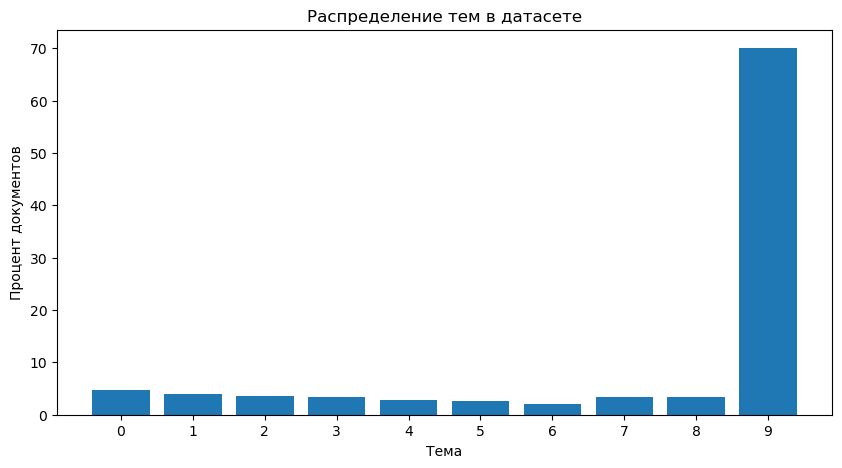

In [26]:
# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(topic_counts.index, topic_percents)
plt.xlabel('Тема')
plt.ylabel('Процент документов')
plt.title('Распределение тем в датасете')
plt.xticks(topic_counts.index)
plt.show()

#### Вывод улучшения векторизации и разбиения тем тематического моделирования
Тематическое моделирование стало более интерпретируемым: темы чётко разделились по семантическим кластерам: праздники (день рождения, Новый год), эмоции (хотеть, любить), повседневная активность (школа, урок, делать) и коммуникация (знать, мочь, говорить). Доминирование Темы 9 (70.1%) с общими разговорными маркерами показывает долю разговорного стиля при общении в соцсетях. При этом остальные темы успешно вычленяют более специфические контексты.


## Классификация

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, dataset['sentiment'], test_size=0.2, random_state=42, stratify=dataset['sentiment']
)
print(f"Обучающая выборка: {X_train.shape}\nТестовая: {X_test.shape}")

Обучающая выборка: (180960, 5000)
Тестовая: (45240, 5000)


### KNeighbours

In [28]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
knn_probs = knn.predict_proba(X_test)[:, 1]

In [29]:
print(f"Accuracy : {accuracy_score(y_test, knn_preds):.4f}")
print(f"Precision: {precision_score(y_test, knn_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, knn_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, knn_preds, average='weighted', zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, knn_probs):.4f}\n")
print(classification_report(y_test, knn_preds, zero_division=0))

Accuracy : 0.6186
Precision: 0.6185
Recall   : 0.6186
F1-score : 0.6184
AUC-ROC  : 0.6640

              precision    recall  f1-score   support

          -1       0.62      0.60      0.61     22302
           1       0.62      0.64      0.63     22938

    accuracy                           0.62     45240
   macro avg       0.62      0.62      0.62     45240
weighted avg       0.62      0.62      0.62     45240



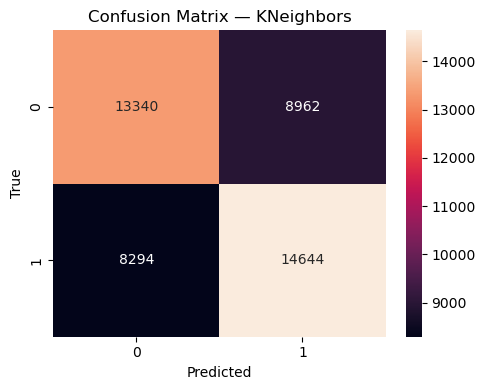

In [30]:
cm = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix — KNeighbors")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

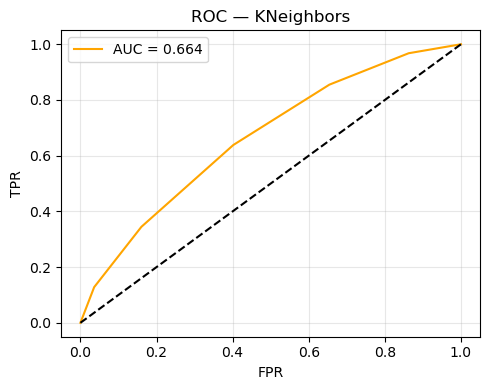

In [31]:
fpr, tpr, _ = roc_curve(y_test, knn_probs, pos_label=1)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="orange")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — KNeighbors")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Вывод
Модель работает чуть лучше случайного угадывания. Метрики сбалансированы, но значения низкие. Для серьёзных задач слабовата, но как базовый вариант хорошо подойдет

### Дерево решений

In [32]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:, 1]

In [33]:
print(f"Accuracy : {accuracy_score(y_test, dt_preds):.4f}")
print(f"Precision: {precision_score(y_test, dt_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, dt_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, dt_preds, average='weighted', zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, dt_probs):.4f}\n")
print(classification_report(y_test, dt_preds, zero_division=0))

Accuracy : 0.5640
Precision: 0.6411
Recall   : 0.5640
F1-score : 0.4883
AUC-ROC  : 0.5737

              precision    recall  f1-score   support

          -1       0.74      0.18      0.28     22302
           1       0.54      0.94      0.69     22938

    accuracy                           0.56     45240
   macro avg       0.64      0.56      0.49     45240
weighted avg       0.64      0.56      0.49     45240



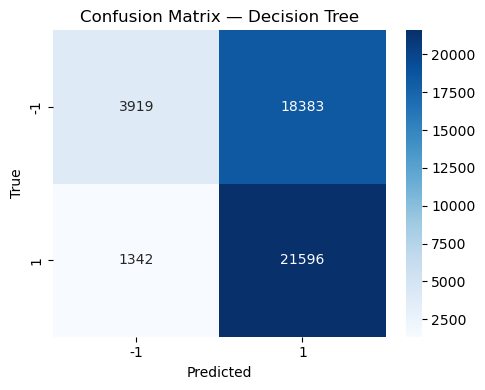

In [34]:
cm = confusion_matrix(y_test, dt_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["-1", "1"], yticklabels=["-1", "1"])
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

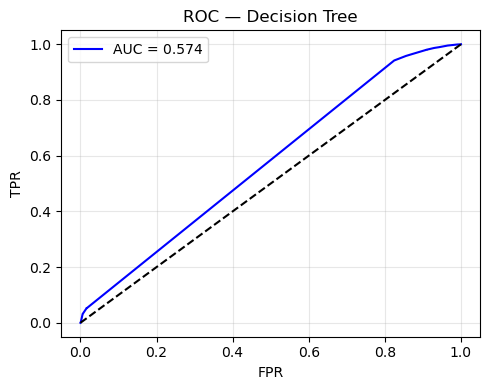

In [35]:
fpr, tpr, _ = roc_curve(y_test, dt_probs, pos_label=1)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="blue")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — Decision Tree")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Вывод
Результаты несколько хуже, чем у предыдущей модели. Модель сильно перекошена: ловит 94% позитива, но пропускает 82% негатива, из-за чего общий F1 всего 0.49. Модель не смогла уловить закономерности в тексте.

### Случайный лес

In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [37]:
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, rf_probs):.4f}\n")
print(classification_report(y_test, rf_preds, zero_division=0))

Accuracy : 0.7038
Precision: 0.7039
Recall   : 0.7038
F1-score : 0.7037
AUC-ROC  : 0.7745

              precision    recall  f1-score   support

          -1       0.71      0.68      0.69     22302
           1       0.70      0.72      0.71     22938

    accuracy                           0.70     45240
   macro avg       0.70      0.70      0.70     45240
weighted avg       0.70      0.70      0.70     45240



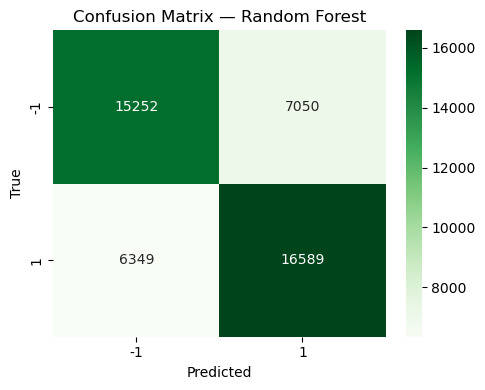

In [38]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["-1", "1"], yticklabels=["-1", "1"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

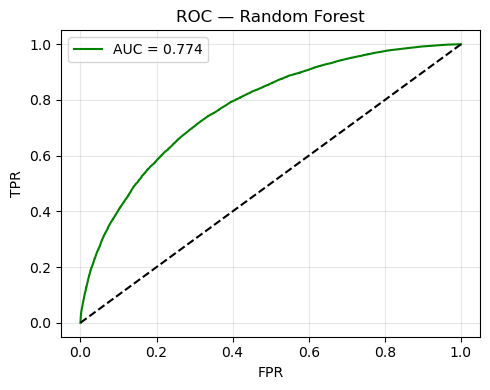

In [39]:
fpr, tpr, _ = roc_curve(y_test, rf_probs, pos_label=1)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="green")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — Random Forest")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Вывод

Лучшая из трёх моделей по всем метрикам. Правильно определяет большинство постов, причём одинаково хорошо и позитив, и негатив. Метрики сбалансированы, модель стабильна, хорошо подходит под нашу задачу

### Сохранение лучшей модели

In [40]:
joblib.dump(rf, "sentiment_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Модель и векторизатор сохранены.")

Модель и векторизатор сохранены.


### Парсинг комментариев с Youtube

In [41]:
from youtube_comment_downloader import YoutubeCommentDownloader

In [42]:
MIN_LEN = 15
comments = []
downloader = YoutubeCommentDownloader()

VIDEO_URLS = [
    "https://www.youtube.com/watch?v=_X2Lj3O2Sv0"
]

In [43]:
for url in VIDEO_URLS:
    try:
        print(f"\nПарсинг: {url[:50]}...")
        count = 0
        for comment in downloader.get_comments_from_url(url):
            txt = comment.get("text", "")
            if re.search(r"[а-яА-ЯёЁ]", txt) and len(txt) >= MIN_LEN:
                clean = re.sub(r"\s+", " ", txt).strip()
                comments.append(clean)
                count += 1
        print(f"Из этого видео: +{count}. русскоязычных всего {len(comments)})")
    except Exception as e:
        print(f"Пропуск видео: {e}")
        continue


Парсинг: https://www.youtube.com/watch?v=_X2Lj3O2Sv0...
Из этого видео: +10910. русскоязычных всего 10910)


#### Сохранение новых комментариев в файл

In [44]:
df = pd.DataFrame(comments, columns=["text"])
df.to_csv("yt_parsing.csv", index=False)
print(f"\nСохранено: {len(df)} комментариев")


Сохранено: 10910 комментариев


#### Загрузка и предобработка новых комментариев

In [45]:
new_raw = pd.read_csv("yt_parsing.csv")
new_df = pd.DataFrame({"text": new_raw["text"].astype(str)})
new_df["text_clean"] = new_df["text"].apply(preprocess_tweet)
new_df = new_df[new_df["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"После очистки осталось: {len(new_df)} комментариев\n")

После очистки осталось: 10774 комментариев



#### Загрузка лучшей модели и векторизатора

In [46]:
best_model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

#### Активное обучение (3 итерации)

In [47]:
main_texts = new_df["text_clean"].tolist()

pool_texts = main_texts.copy()
history = []

labeled_texts = []
labeled_labels = []

for i in range(3):
    if len(pool_texts) < 550: 
        break
    
    batch = pool_texts[:550]
    pool_texts = pool_texts[550:]
    
    if labeled_texts:
        combined = labeled_texts + batch
        X_all = vectorizer.transform(combined)
        X_labeled = X_all[:len(labeled_texts)]
        X_batch = X_all[len(labeled_texts):]

        best_model.fit(X_labeled, labeled_labels)
    else:
        X_batch = vectorizer.transform(batch)
    
    probs = best_model.predict_proba(X_batch)[:, 1]
    pos_idx = np.where(probs > 0.8)[0]
    neg_idx = np.where(probs < 0.2)[0]
    
    for idx in pos_idx:
        labeled_texts.append(batch[idx])
        labeled_labels.append(1)
    for idx in neg_idx:
        labeled_texts.append(batch[idx])
        labeled_labels.append(-1)
    
    history.append({
        "Итерация": i+1, 
        "Взято": 550, 
        "Добавлено": len(pos_idx) + len(neg_idx), 
        "Корпус": len(labeled_texts)
    })
    print(f"Итерация {i+1}: Добавлено {len(pos_idx)+len(neg_idx)}. Размер корпуса: {len(labeled_texts)}")

Итерация 1: Добавлено 151. Размер корпуса: 151
Итерация 2: Добавлено 252. Размер корпуса: 403
Итерация 3: Добавлено 439. Размер корпуса: 842


#### Распределение псевдо-меток новых комментариев

In [48]:
X_new_all = vectorizer.transform(new_df["text_clean"])
new_preds = best_model.predict(X_new_all)
new_proba = best_model.predict_proba(X_new_all)[:, 1]

pos_cnt = (new_preds == 1).sum()
neg_cnt = (new_preds == -1).sum()
print(f"  Позитив: {pos_cnt:,} ({pos_cnt/len(new_preds)*100:.1f}%)")
print(f"  Негатив: {neg_cnt:,} ({neg_cnt/len(new_preds)*100:.1f}%)\n")

  Позитив: 10,018 (93.0%)
  Негатив: 756 (7.0%)



#### Финальные метрики после дообучения

In [49]:
final_preds = best_model.predict(X_test)
final_proba = best_model.predict_proba(X_test)[:, 1]
final_acc = accuracy_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds, average="weighted")
final_auc = roc_auc_score(y_test, final_proba)

print(f"  Accuracy: {final_acc:.4f}")
print(f"  F1-score: {final_f1:.4f}")
print(f"  AUC-ROC:  {final_auc:.4f}\n")

  Accuracy: 0.5205
  F1-score: 0.3866
  AUC-ROC:  0.5800



### Визуализация распределения новых данных

#### Распределение по классам

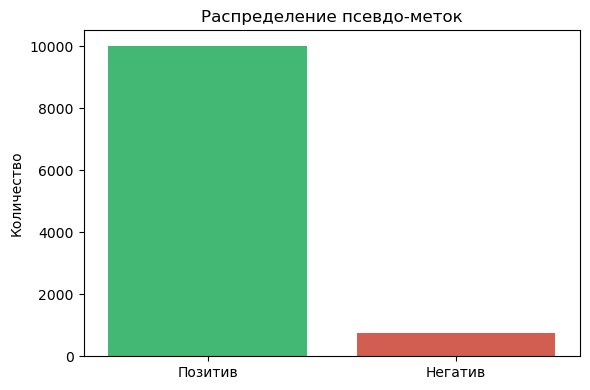

In [50]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Позитив", "Негатив"], y=[pos_cnt, neg_cnt], palette=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Распределение псевдо-меток")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()

#### Гистограмма уверенности

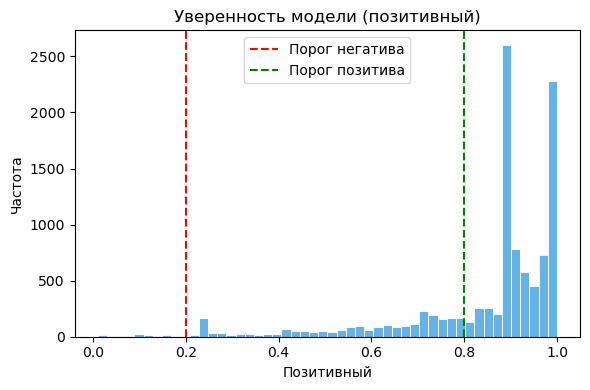

In [51]:
plt.figure(figsize=(6, 4))
sns.histplot(new_proba, bins=50, color="#3498db", edgecolor="white")
plt.axvline(0.2, color="red", ls="--", label="Порог негатива")
plt.axvline(0.8, color="green", ls="--", label="Порог позитива")
plt.title("Уверенность модели (позитивный)")
plt.xlabel("Позитивный")
plt.ylabel("Частота")
plt.legend()
plt.tight_layout()
plt.show()

#### Сравнение метрик до дообучения и после

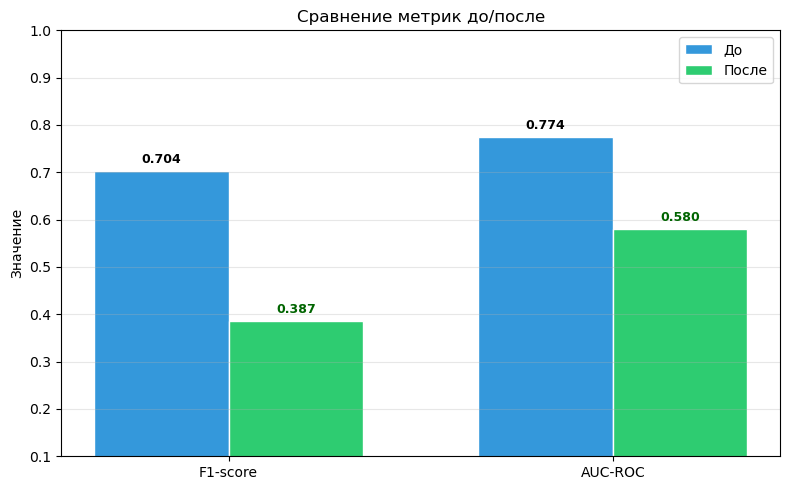

In [52]:
before_f1, before_auc = 0.7037, 0.7745
metrics = pd.DataFrame({
    "Метрика": ["F1-score", "AUC-ROC"],
    "До": [before_f1, before_auc],
    "После": [final_f1, final_auc] 
})

plt.figure(figsize=(8, 5))
x = np.arange(len(metrics["Метрика"]))
width = 0.35

plt.bar(x - width/2, metrics["До"], width, label="До", color="#3498db", edgecolor='white')
plt.bar(x + width/2, metrics["После"], width, label="После", color="#2ecc71", edgecolor='white')

plt.xticks(x, metrics["Метрика"], rotation=0)
plt.ylabel("Значение")
plt.title("Сравнение метрик до/после")
plt.ylim(0.1, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (before, after) in enumerate(zip(metrics["До"], metrics["После"])):
    if pd.notna(before):
        plt.text(i - width/2, before + 0.01, f"{before:.3f}", 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    if pd.notna(after):
        plt.text(i + width/2, after + 0.01, f"{after:.3f}", 
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

#### Матрица ошибок

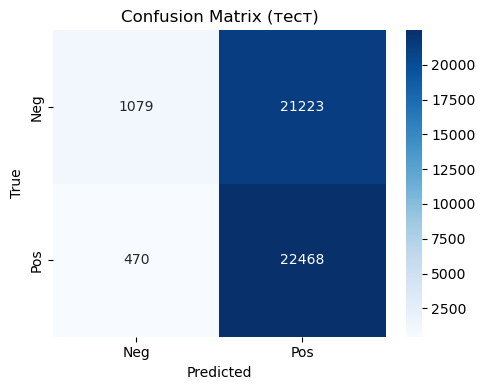

График сохранён как confusion_matrix.png


In [53]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.title("Confusion Matrix (тест)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()
print("График сохранён как confusion_matrix.png")

#### Вывод
Изначально классификатор показывал стабильное качество (F1 = 0.70), но после цикла активного обучения метрики снизились до F1 = 0.38 из-за накопления шума при автоматической псевдоразметке. Модель начала постепенно переобучаться на собственных ошибочных предсказаниях. Тем не менее, показал необходимость дополнительной очистки данных для сохранения точности при правильном подходе

### Приложения с API

#### Анализ позитивного комментария

##### Что сделано: 
Протестирована модель на тексте "сегодня был отличный день"

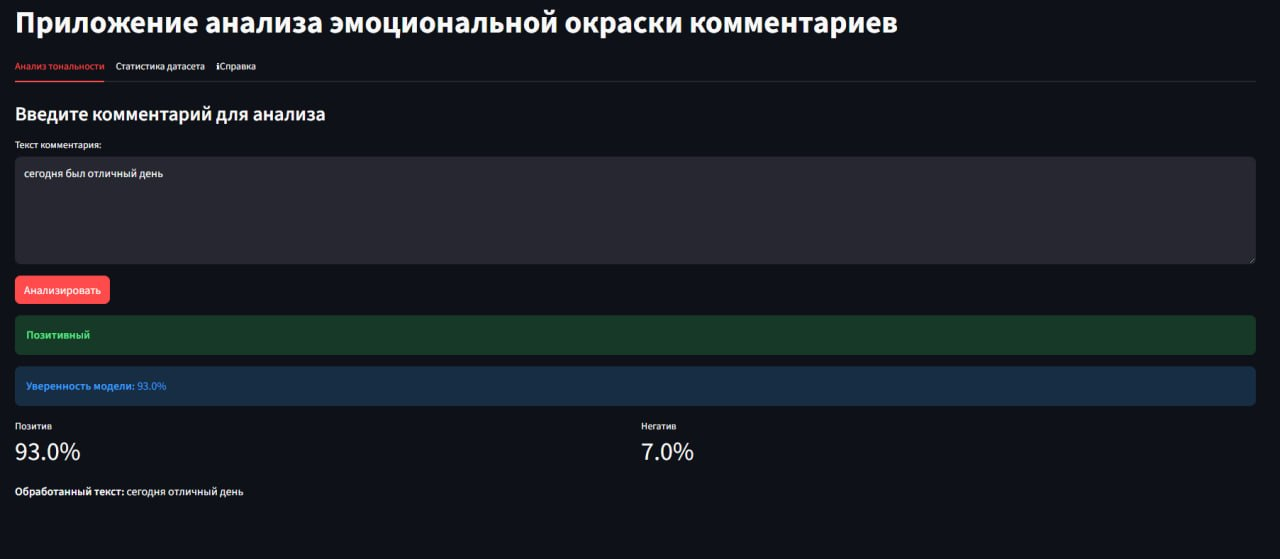

##### Результат: 
Модель корректно определила позитивную тональность с уверенностью 93% (позитив 93%, негатив 7%)

#### Анализ отрицательного комментария

##### Что сделано: 
Протестирована модель на тексте "сегодня был ужасный день"

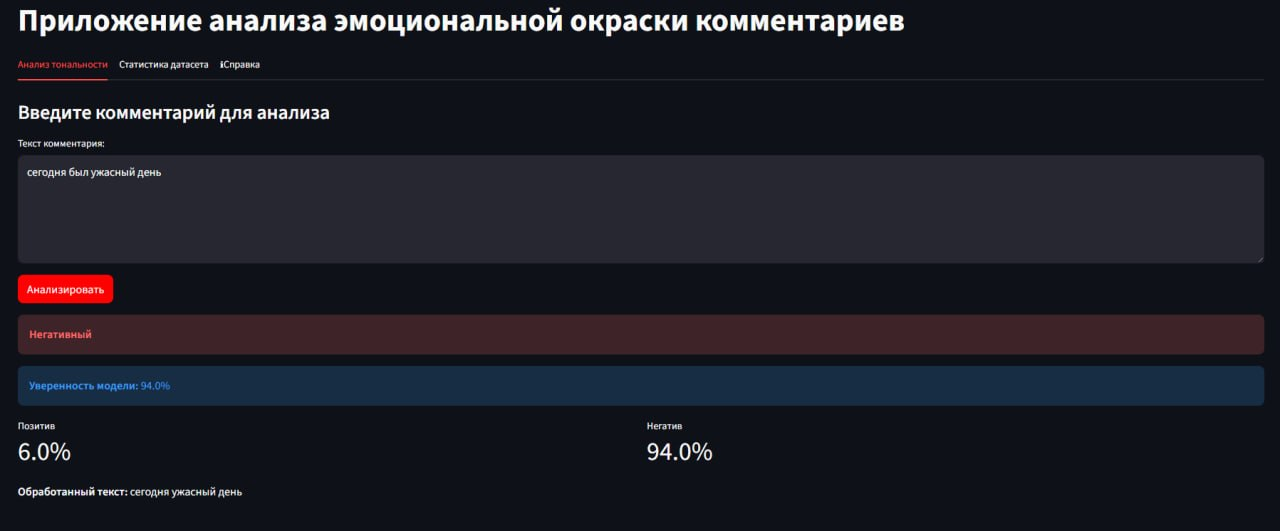

##### Результат: 
Модель корректно определила негативную тональность с уверенностью 94% (негатив 94%, позитив 6%)

#### Валидация ввода

##### Что сделано: 
Реализована проверка на пустой ввод

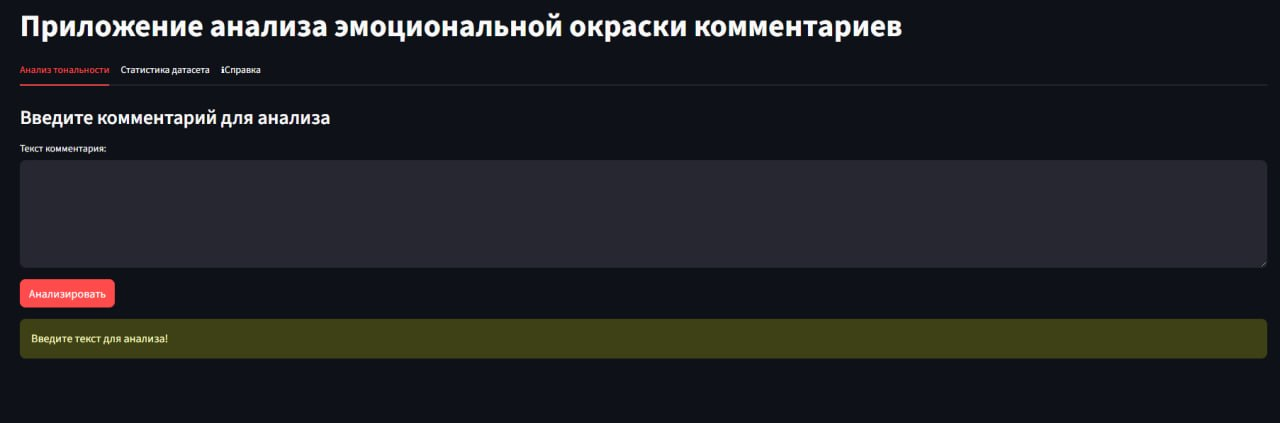

##### Результат: 
При попытке анализа без текста появляется предупреждение "Введите текст для анализа!"

#### Статистика датасета

##### Что сделано: 
Создана визуализация статистики обучающей выборки

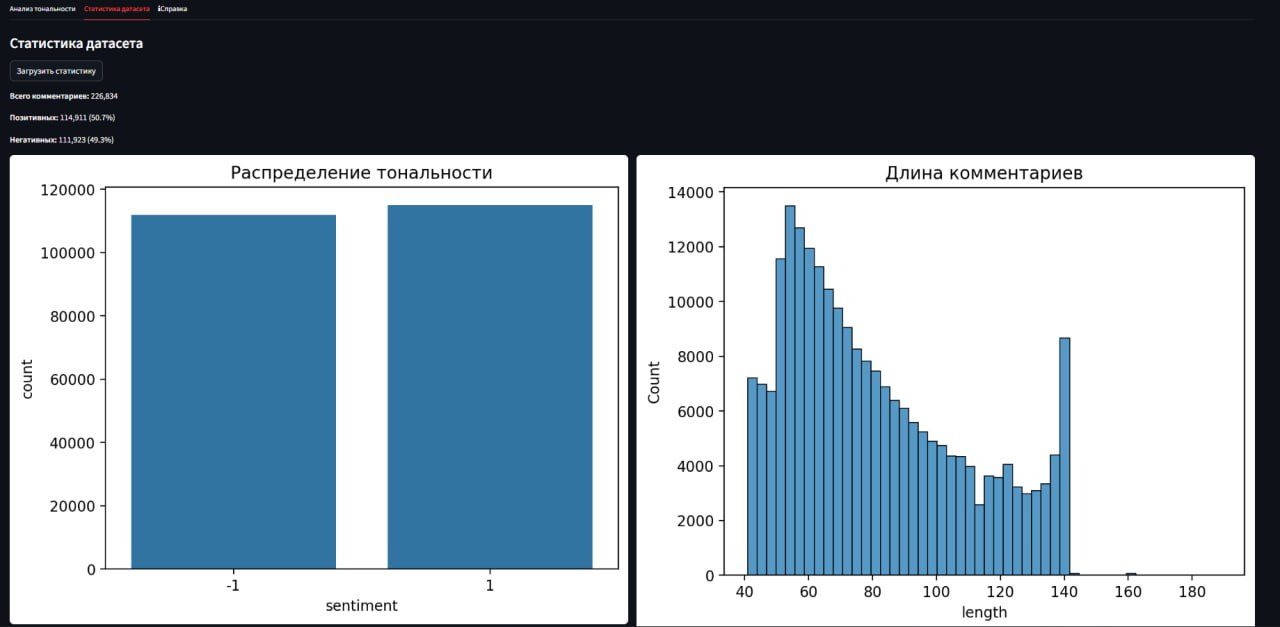

##### Результат:
Показано распределение: 226,834 комментариев (50.7% позитивных, 49.3% негативных) и гистограмма длин комментариев (преимущественно 50-70 символов)

#### Справка по командам

##### Что сделано: 
Создана страница документации с описанием API endpoints и инструкциями по запуску

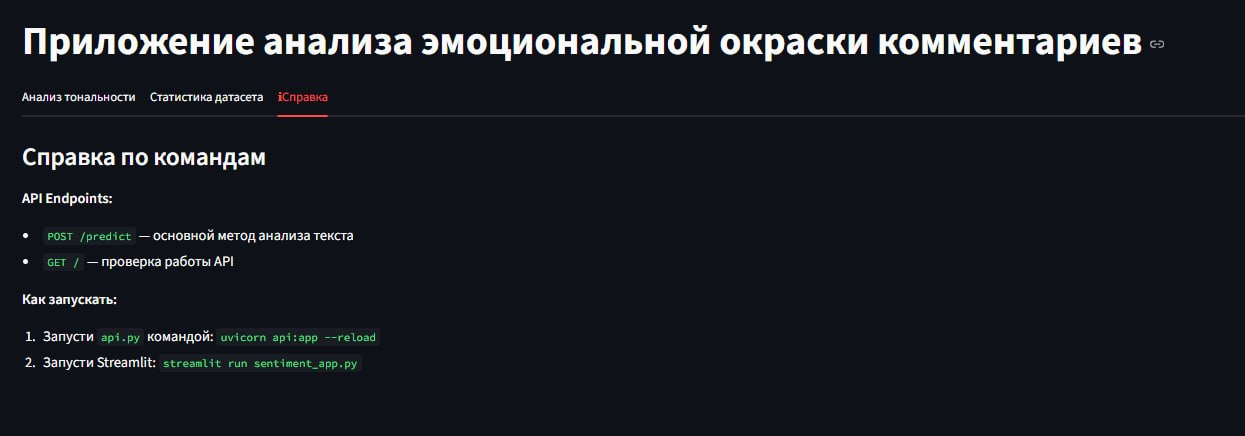

##### Что сделано: 
Создана страница документации с описанием API endpoints и инструкциями по запуску